# DATA 266 Lab 1, Task 2: Yelp Polarity sentiment classification

Three models trained with `python src/sentiment.py --config src/cfg_<name>.yaml --out_dir .` and compared with `--mode compare` (raw logs in `logs/`). No pretrained embeddings or language models: every embedding is learned from scratch. This notebook loads the saved results and checkpoints and shows preprocessing, the models, training, all metrics, the statistical comparison, live predictions and the error review.

In [1]:
import os, sys, json, glob
from argparse import Namespace
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "src":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import Image as ShowImage, display
import sentiment

device = "cuda" if torch.cuda.is_available() else "cpu"
RUNS = [Path(p).name.replace("_best.pt", "") for p in sorted(glob.glob("checkpoints/*_best.pt"))]
print("member folder:", ROOT.name, "| runs:", RUNS)
print("torch", torch.__version__, "| device:", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")

member folder: akhilesh | runs: ['baseline', 'exp1_cnn', 'exp2_bilstm']
torch 2.11.0+cu128 | device: NVIDIA GeForce RTX 5090


## 2.1 Data analysis and preprocessing

Class balance, review lengths, missing and duplicate entries, measured on the 120,000-review training subsample (balanced draw from the 560,000-review train split) and the full 38,000-review test split.

In [2]:
eda = json.load(open("outputs/eda/eda.json", encoding="utf-8"))
flat = {}
for k, v in eda.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            flat[f"{k}.{k2}"] = v2
    else:
        flat[k] = v
pd.DataFrame({"value": flat})

,value
full_train_size,560000.000000
full_test_size,38000.000000
full_train_class_counts.0,280000.000000
full_train_class_counts.1,280000.000000
train_missing_or_empty,0.000000
train_exact_duplicates,0.000000
test_missing_or_empty,0.000000
train_subsample_size,120000.000000
train_subsample_class_counts.0,59992.000000
train_subsample_class_counts.1,60008.000000


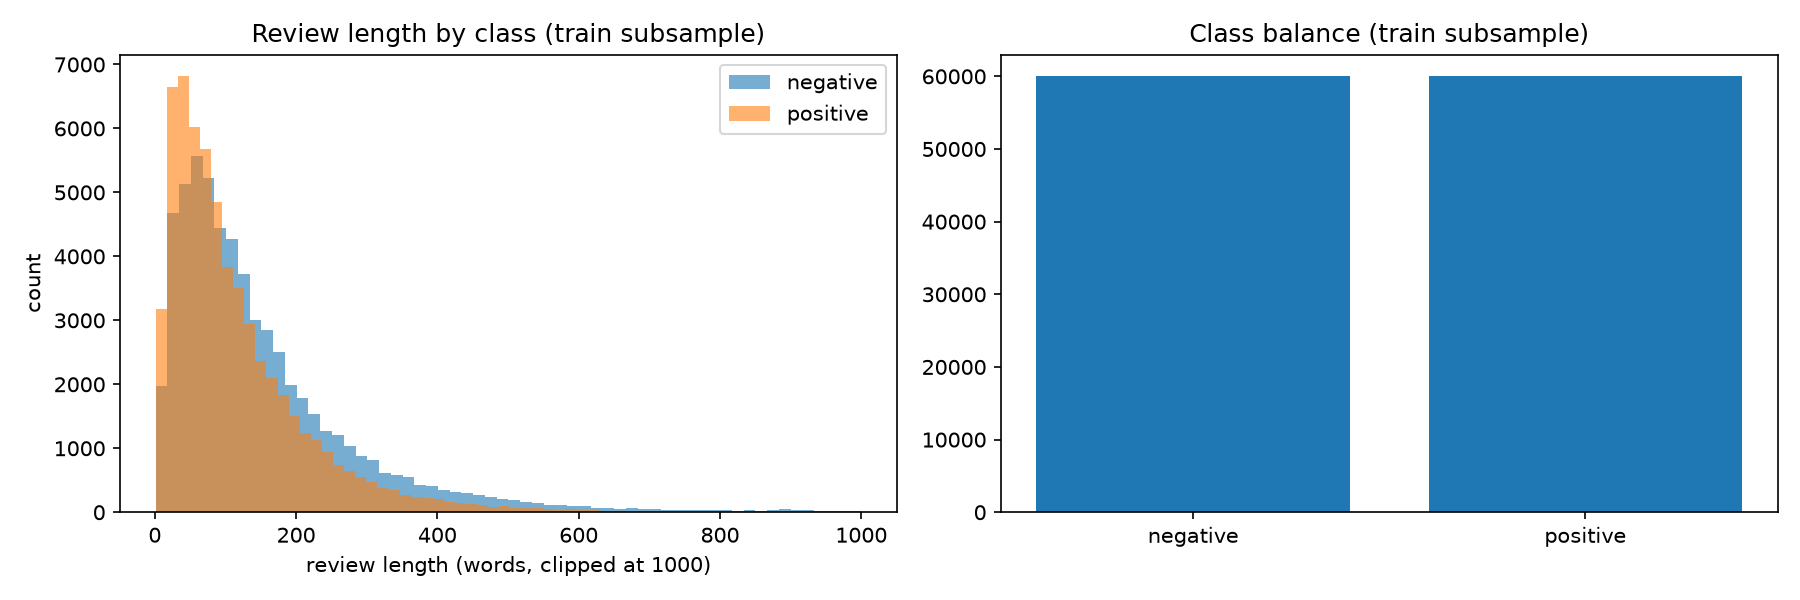

In [3]:
display(ShowImage("outputs/eda/eda.png"))

### Cleaning and tokenisation

Lowercasing, turning "n't" into " not", removing punctuation, digits and other non-letters, removing English stopwords while keeping negation words, and Porter stemming. The tokens are then mapped to a vocabulary of words seen at least 3 times in training (index 0 = padding, 1 = unknown) and padded or cut to 256 tokens.

In [4]:
ck0 = torch.load(f"checkpoints/{RUNS[0]}_best.pt", map_location="cpu")
a0 = Namespace(**ck0["args"])
clean = sentiment.make_cleaner(a0)
itos = ck0["itos"]; stoi = {w: i for i, w in enumerate(itos)}
print("vocabulary size:", len(itos))
print("most frequent tokens:", itos[2:32])

for review in ["The pasta wasn't good at all, and the waiter was RUDE!!!",
               "Loved it -- best tacos in Phoenix, can't wait to come back :)"]:
    toks = clean(review)
    ids, lens = sentiment.encode([toks], stoi, a0.max_len)
    print("\nraw   :", review)
    print("tokens:", toks)
    print("ids   :", ids[0, :lens[0]].tolist())

vocabulary size: 26895
most frequent tokens: ['not', 'place', 'food', 'good', 'like', 'time', 'just', 'order', 'servic', 'did', 'great', 'no', 'realli', 'tri', 'look', 'want', 'come', 'got', 'wait', 'restaur', 've', 'make', 'ask', 'love', 'price', 'nice', 'never', 'peopl', 'drink', 'went']

raw   : The pasta wasn't good at all, and the waiter was RUDE!!!
tokens: ['pasta', 'not', 'good', 'waiter', 'rude']
ids   : [470, 2, 5, 195, 242]

raw   : Loved it -- best tacos in Phoenix, can't wait to come back :)
tokens: ['love', 'best', 'taco', 'phoenix', 'ca', 'not', 'wait', 'come']
ids   : [25, 43, 214, 457, 105, 2, 20, 18]


## 2.2 Models

All three learn their own 128-dimensional word embeddings from scratch.

- **Baseline (bag of words):** masked mean of the word embeddings, then a small MLP. Ignores word order.
- **Experimental 1 (CNN):** 1D convolutions over the embeddings with several window widths, max-pooled over the review. Captures short phrases.
- **Experimental 2 (BiLSTM):** bidirectional LSTM over the whole review, max-pooled over time. Captures word order and long-range context.

In [5]:
models = {}
rows = []
for r in RUNS:
    ck = torch.load(f"checkpoints/{r}_best.pt", map_location=device)
    a = Namespace(**ck["args"])
    m = sentiment.build_model(len(ck["itos"]), a).to(device)
    m.load_state_dict(ck["model"]); m.eval()
    models[r] = (m, a, ck)
    rows.append({"run": r, "model": a.model, "emb_dim": a.emb_dim, "hidden": a.hidden, "kernels": a.kernels if a.model == "cnn" else "",
                 "n_filters": a.n_filters if a.model == "cnn" else "", "pooling": a.pooling if a.model in ("bilstm", "bigru") else "",
                 "dropout": a.dropout, "lr": a.lr, "batch_size": a.batch_size, "best_epoch": ck["epoch"],
                 "parameters": sum(p.numel() for p in m.parameters())})
display(pd.DataFrame(rows))
for r, (m, a, ck) in models.items():
    print(f"\n=== {r} ===\n{m}")

,run,model,emb_dim,hidden,kernels,n_filters,pooling,dropout,lr,batch_size,best_epoch,parameters
0,baseline,bow,128,128,,,,0.3,0.002,256,4,3459201
1,exp1_cnn,cnn,128,128,"[3, 4, 5]",128,,0.5,0.001,256,6,3639937
2,exp2_bilstm,bilstm,128,128,,,max,0.3,0.001,128,3,3707009



=== baseline ===
BoWMean(
  (emb): Embedding(26895, 128, padding_idx=0)
  (head): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

=== exp1_cnn ===
TextCNN(
  (emb): Embedding(26895, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (drop): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=1, bias=True)
)

=== exp2_bilstm ===
BiRNN(
  (emb): Embedding(26895, 128, padding_idx=0)
  (rnn): LSTM(128, 128, batch_first=True, bidirectional=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


### Training curves (early stopping on validation loss, patience 2)

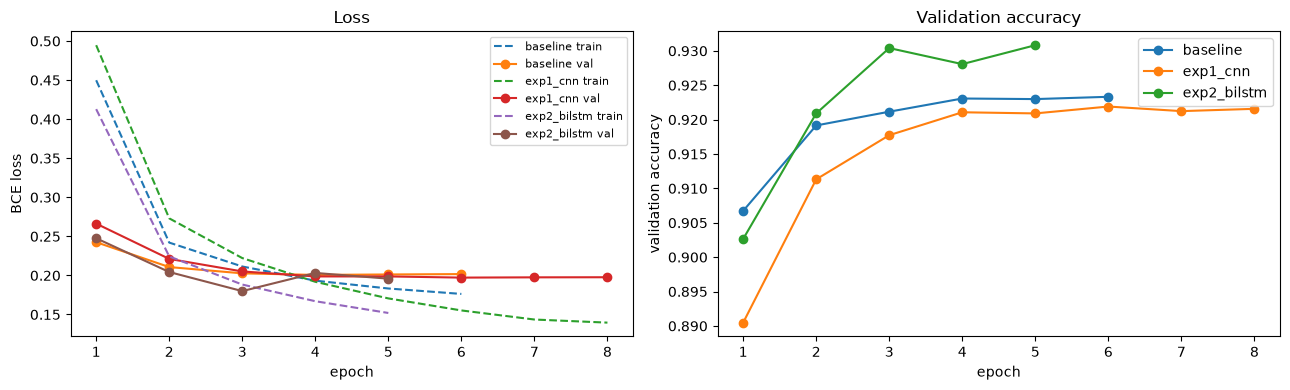

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for r in RUNS:
    h = pd.DataFrame(json.load(open(f"outputs/{r}/history.json")))
    ax[0].plot(h.epoch, h.train_loss, "--", label=f"{r} train")
    ax[0].plot(h.epoch, h.val_loss, "o-", label=f"{r} val")
    ax[1].plot(h.epoch, h.val_acc, "o-", label=r)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("BCE loss"); ax[0].legend(fontsize=8); ax[0].set_title("Loss")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation accuracy"); ax[1].legend(); ax[1].set_title("Validation accuracy")
plt.tight_layout(); plt.show()

## Evaluation on the 38,000-review test set

Accuracy, precision/recall/F1 (macro, micro, weighted), confusion matrix, ROC-AUC, PR-AUC, MCC, Brier score, expected calibration error, 95% bootstrap confidence intervals (1,000 resamples), per-slice macro-F1 and error rate, parameters, training time, throughput, peak memory and hardware.

In [7]:
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 80)
pd.read_csv("outputs/comparison_table.csv")

,metric,baseline,exp1_cnn,exp2_bilstm
0,model_type,bow,cnn,bilstm
1,accuracy,0.922868,0.924632,0.930921
2,precision_macro,0.922874,0.924635,0.930922
3,recall_macro,0.922868,0.924632,0.930921
4,f1_macro,0.922868,0.924631,0.930921
5,precision_micro,0.922868,0.924632,0.930921
6,recall_micro,0.922868,0.924632,0.930921
7,f1_micro,0.922868,0.924632,0.930921
8,precision_weighted,0.922874,0.924635,0.930922
9,recall_weighted,0.922868,0.924632,0.930921


baseline


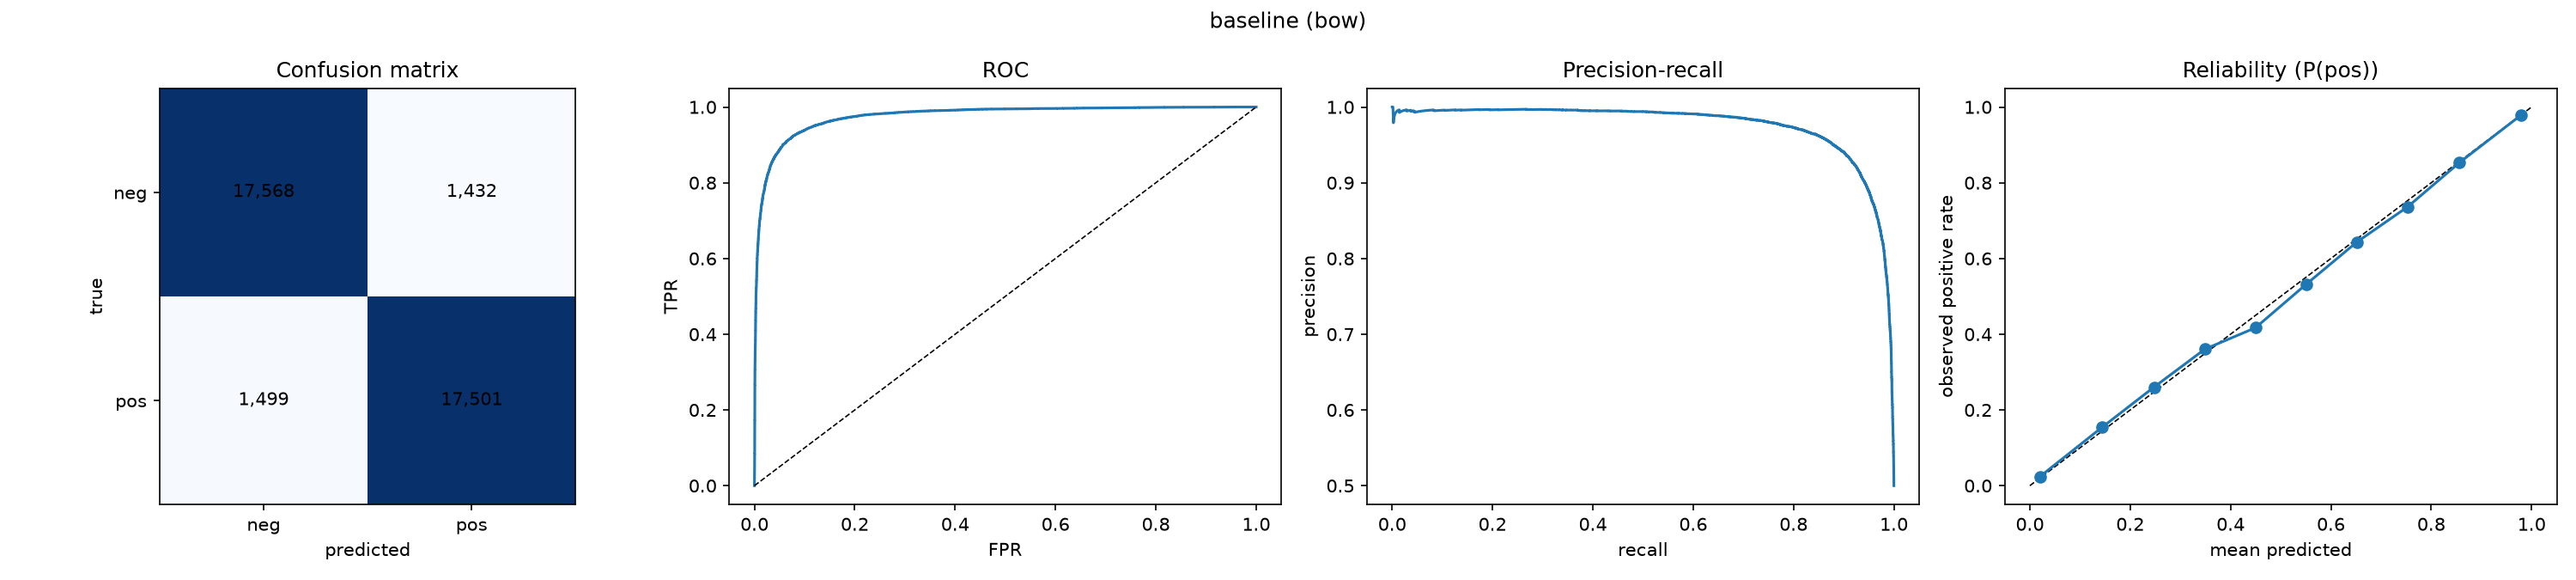

exp1_cnn


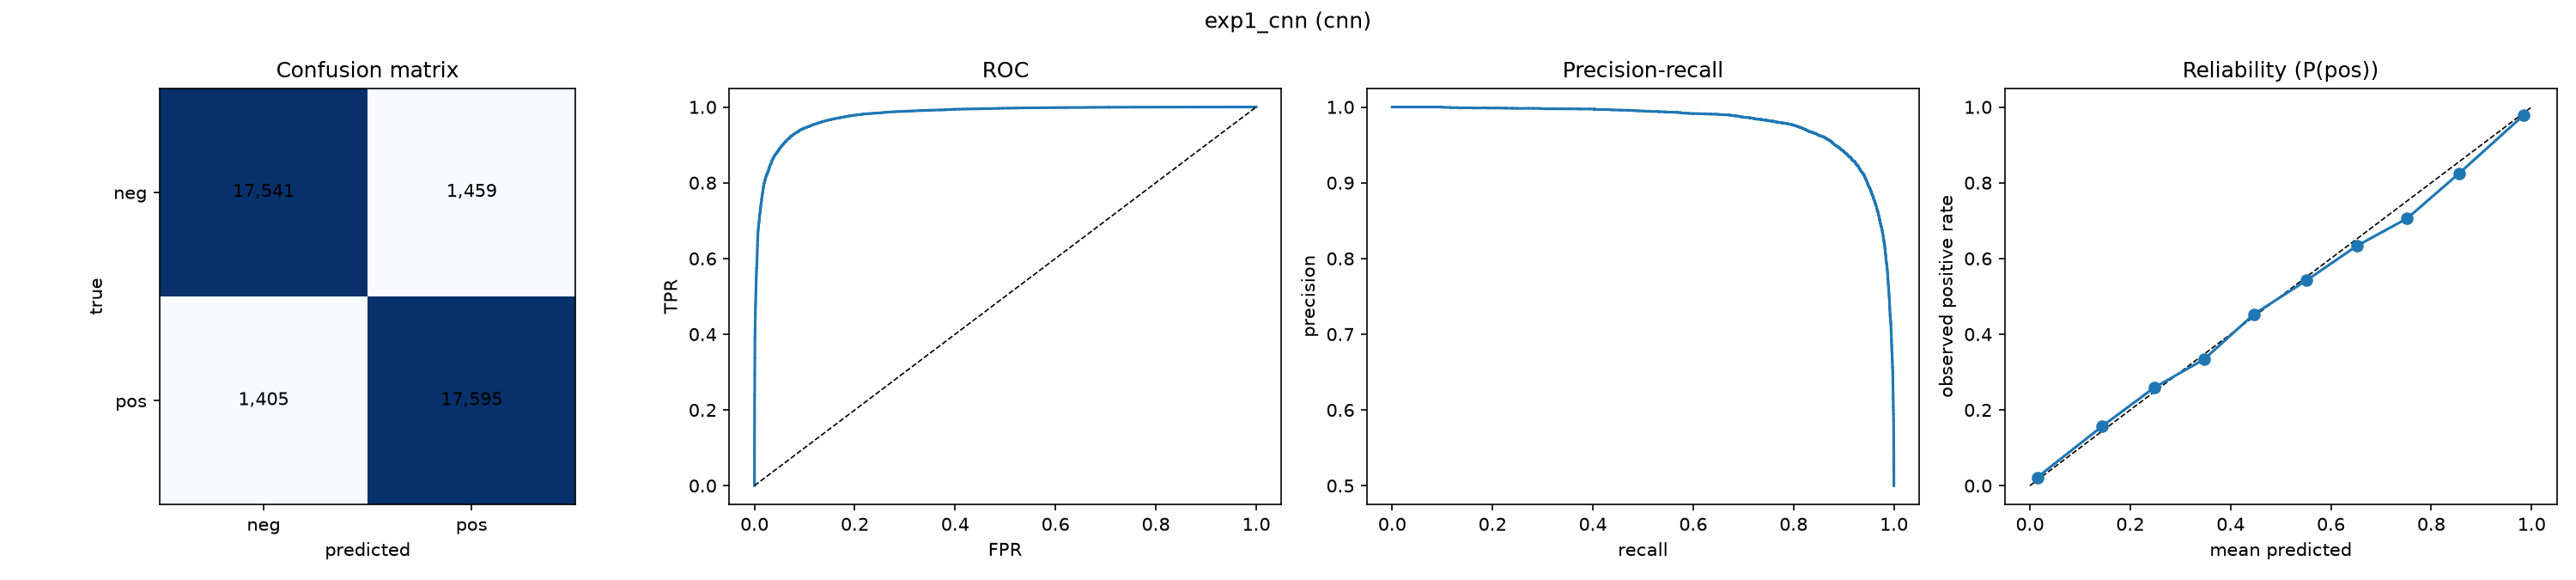

exp2_bilstm


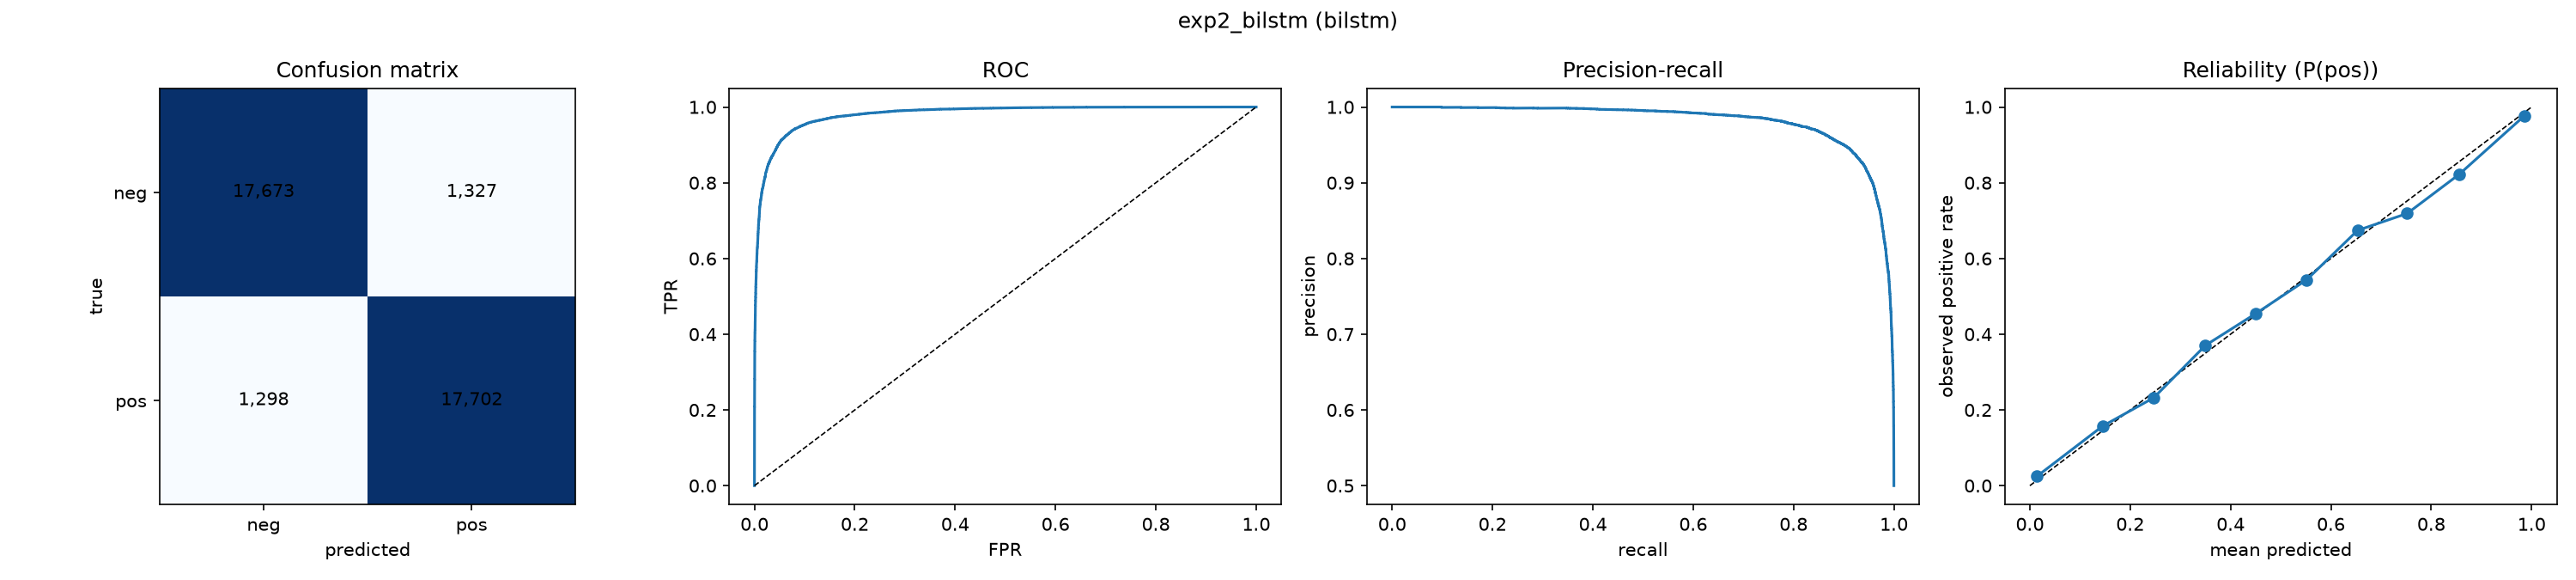

In [8]:
for r in RUNS:
    print(r)
    display(ShowImage(f"outputs/{r}/eval_plots.png", width=1000))

### Robustness: macro-F1 and error rate per slice

In [9]:
sl = []
for r in RUNS:
    d = pd.read_csv(f"outputs/{r}/slices.csv"); d.insert(0, "run", r); sl.append(d)
pd.concat(sl).pivot(index="slice", columns="run", values=["macro_f1", "error_rate"]).round(4)

macro_f1                      error_rate           \
run                   baseline exp1_cnn exp2_bilstm   baseline exp1_cnn   
slice                                                                     
contains negation       0.9156   0.9188      0.9256     0.0816   0.0786   
long (> 142 words)      0.9212   0.9234      0.9262     0.0762   0.0741   
medium (65-142 words)   0.9243   0.9274      0.9319     0.0757   0.0726   
no negation             0.9111   0.9083      0.9165     0.0642   0.0660   
short (<= 65 words)     0.9181   0.9182      0.9301     0.0795   0.0794   

                                   
run                   exp2_bilstm  
slice                              
contains negation          0.0720  
long (> 142 words)         0.0714  
medium (65-142 words)      0.0681  
no negation                0.0604  
short (<= 65 words)        0.0678

## 2.3 Paired McNemar tests (baseline vs each experimental model)

b = reviews the baseline gets right and the experimental model gets wrong; c = the reverse. A p-value below 0.05 means the two models' errors differ by more than chance.

In [10]:
mr = pd.read_csv("metrics_report.csv")
mr[mr.metric.str.startswith("mcnemar")]

,model,metric,value
129,mcnemar_baseline,mcnemar_vs_exp1_cnn_b_base_right_exp_wrong,916
130,mcnemar_baseline,mcnemar_vs_exp1_cnn_c_base_wrong_exp_right,983
131,mcnemar_baseline,mcnemar_vs_exp1_cnn_chi2_cc,2.29384
132,mcnemar_baseline,mcnemar_vs_exp1_cnn_p_chi2_cc,0.129888
133,mcnemar_baseline,mcnemar_vs_exp1_cnn_p_exact,0.129867
134,mcnemar_baseline,mcnemar_vs_exp2_bilstm_b_base_right_exp_wrong,813
135,mcnemar_baseline,mcnemar_vs_exp2_bilstm_c_base_wrong_exp_right,1119
136,mcnemar_baseline,mcnemar_vs_exp2_bilstm_chi2_cc,48.1496
137,mcnemar_baseline,mcnemar_vs_exp2_bilstm_p_chi2_cc,3.94912e-12
138,mcnemar_baseline,mcnemar_vs_exp2_bilstm_p_exact,3.57014e-12


## Live predictions

The same sentences through all three models, including negation and contrast cases.

In [11]:
tests = ["The food was good.",
         "The food was not good.",
         "Good food but terrible service, never coming back.",
         "I expected it to be awful, but honestly it was fantastic.",
         "It was fine enough, nothing special.",
         "Not bad at all, would go again."]
out = []
for t in tests:
    row = {"review": t}
    for r, (m, a, ck) in models.items():
        s2i = {w: i for i, w in enumerate(ck["itos"])}
        ids, lens = sentiment.encode([sentiment.make_cleaner(a)(t)], s2i, a.max_len)
        with torch.no_grad():
            p = torch.sigmoid(m(torch.from_numpy(ids).to(device), torch.from_numpy(lens).to(device))).item()
        row[f"{r} P(pos)"] = round(p, 3)
    out.append(row)
pd.DataFrame(out)

,review,baseline P(pos),exp1_cnn P(pos),exp2_bilstm P(pos)
0,The food was good.,0.935,0.858,0.863
1,The food was not good.,0.188,0.072,0.144
2,"Good food but terrible service, never coming back.",0.006,0.005,0.035
3,"I expected it to be awful, but honestly it was fantastic.",0.000,0.633,0.281
4,"It was fine enough, nothing special.",0.000,0.047,0.091
5,"Not bad at all, would go again.",0.000,0.190,0.274


## Error review (best model)

The 20 errors reviewed by hand in `failure_analysis.md`: 5 confident false positives, 5 confident false negatives, 5 near-threshold errors and 5 from the weakest slice.

In [12]:
best = RUNS[-1]
try:
    er = pd.read_csv(f"outputs/{best}/error_review.csv", encoding="utf-8")
except UnicodeDecodeError:  # file saved with the Windows code page
    er = pd.read_csv(f"outputs/{best}/error_review.csv", encoding="cp1252")
er["text"] = er["text"].str.slice(0, 160) + "..."
er[["category", "test_index", "true_label", "p_positive", "text"]]

,category,test_index,true_label,p_positive,text
0,confident_false_positive,408,0,0.9992,Though I'm a Copper enthusiast when it comes to getting my Indian fix in Cha...
1,confident_false_positive,10770,0,0.9990,"Very small portions, but good food. Had a perfectly cooked fillet minion, bu..."
2,confident_false_positive,29330,0,0.9987,Wow love the place and everything is very clean and new! Great place to com...
3,confident_false_positive,11699,0,0.9985,"I work right down the street from Tammie Coe on Roosevelt, and for months my..."
4,confident_false_positive,25701,0,0.9984,I had both a red tinga as well as a chili verde gordita. I also enjoyed a la...
5,confident_false_negative,22807,1,0.0003,EDIT: They really did change the service up since I last posted this. Horri...
6,confident_false_negative,22451,1,0.0006,"The food is crap. I'm not trying to be mean, but it really is horrible. I'..."
7,confident_false_negative,11808,1,0.0007,It was Anniversary time! But we didn't' want to spend a ton of money on food...
8,confident_false_negative,21215,1,0.0007,Last night several parents came in with over 15 children to celebrate their ...
9,confident_false_negative,34219,1,0.0013,I tried them when they first opened and know. food quality has improved alot...
